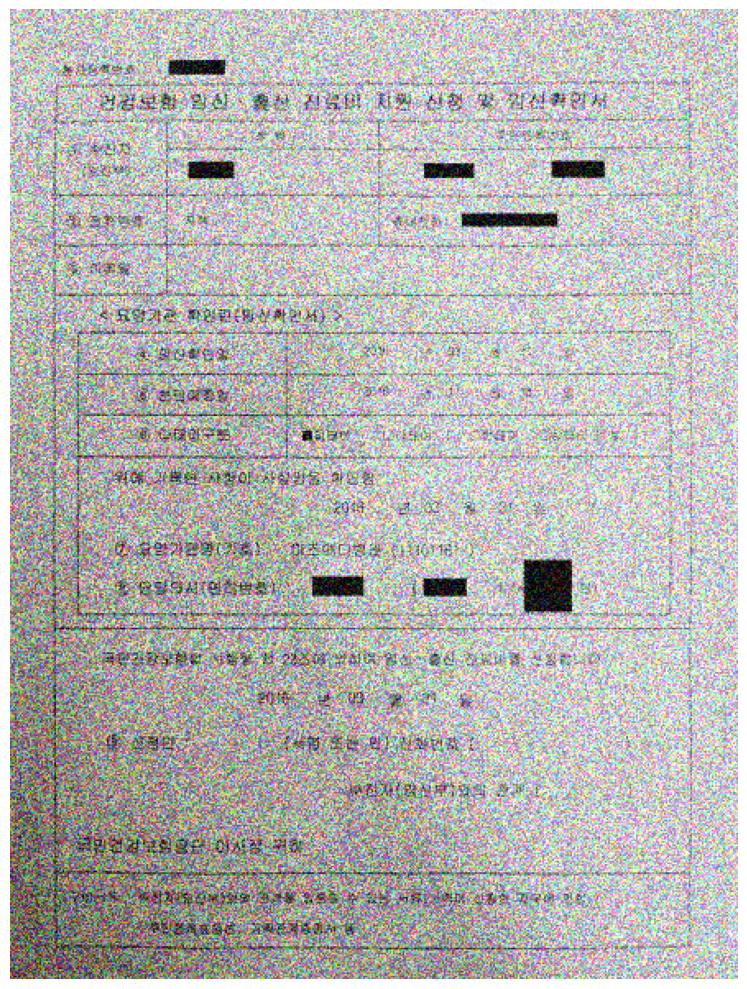

In [1]:
from augraphy import *
import cv2
import matplotlib.pyplot as plt

# 이미지 로드
image = cv2.imread("./0a4adccbb7fe73e0.jpg")
# 25 ~ 90 노이즈 추가: 전반적으로 균일한 회색 노이즈가 덧입혀져 있습니다.
# SubtleNoise 인스턴스 생성
subtle_noise = SubtleNoise(
    subtle_range=90,  # 노이즈 강도 설정
    p=1.0            # 100% 확률로 적용
)

# 노이즈 적용
noisy_image = subtle_noise(image)


plt.figure(figsize=(30, 10))
    
plt.imshow(noisy_image)
plt.axis('off')
plt.tight_layout()
plt.show()



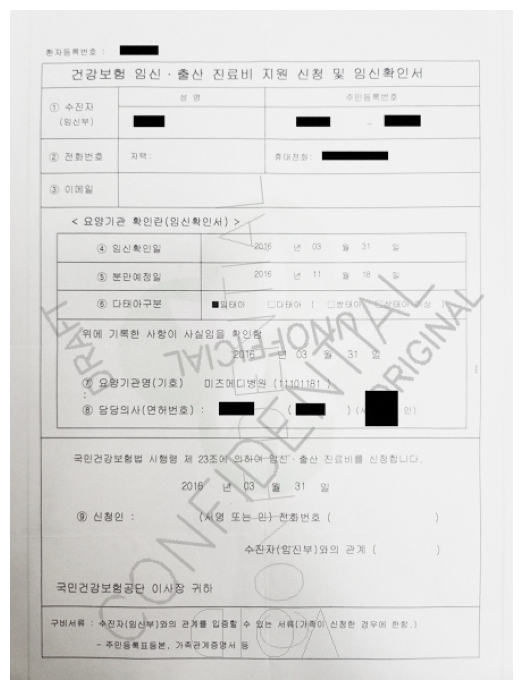

In [2]:
from augraphy import *
import cv2

paper_phase = []
    
for i in range(7):  # 7개의 서로 다른 워터마크
    watermark = WaterMark(
        watermark_word="random",
        watermark_font_size=(1, 2),  
        watermark_font_thickness=(1, 2),
        watermark_rotation=(i*30, i*30 + 60),  # 각기 다른 회전
        watermark_location="random",
        watermark_color=(200, 200, 200),
        watermark_method="darken",
        p=1.0
    )
    paper_phase.append(watermark)

# 완전한 파이프라인
pipeline = AugraphyPipeline(
    ink_phase=[
        SubtleNoise(subtle_range=5, p=0.5)
    ],
    paper_phase=paper_phase,
    post_phase=[
        Brightness(brightness_range=(0.95, 1.05), p=0.3)
    ]
)

image = cv2.imread("./0a4adccbb7fe73e0.jpg")
# 이미지 처리
result = pipeline.augment(image)


plt.figure(figsize=(20, 7))
    
plt.imshow(result['output'])
plt.axis('off')
plt.tight_layout()
plt.show()

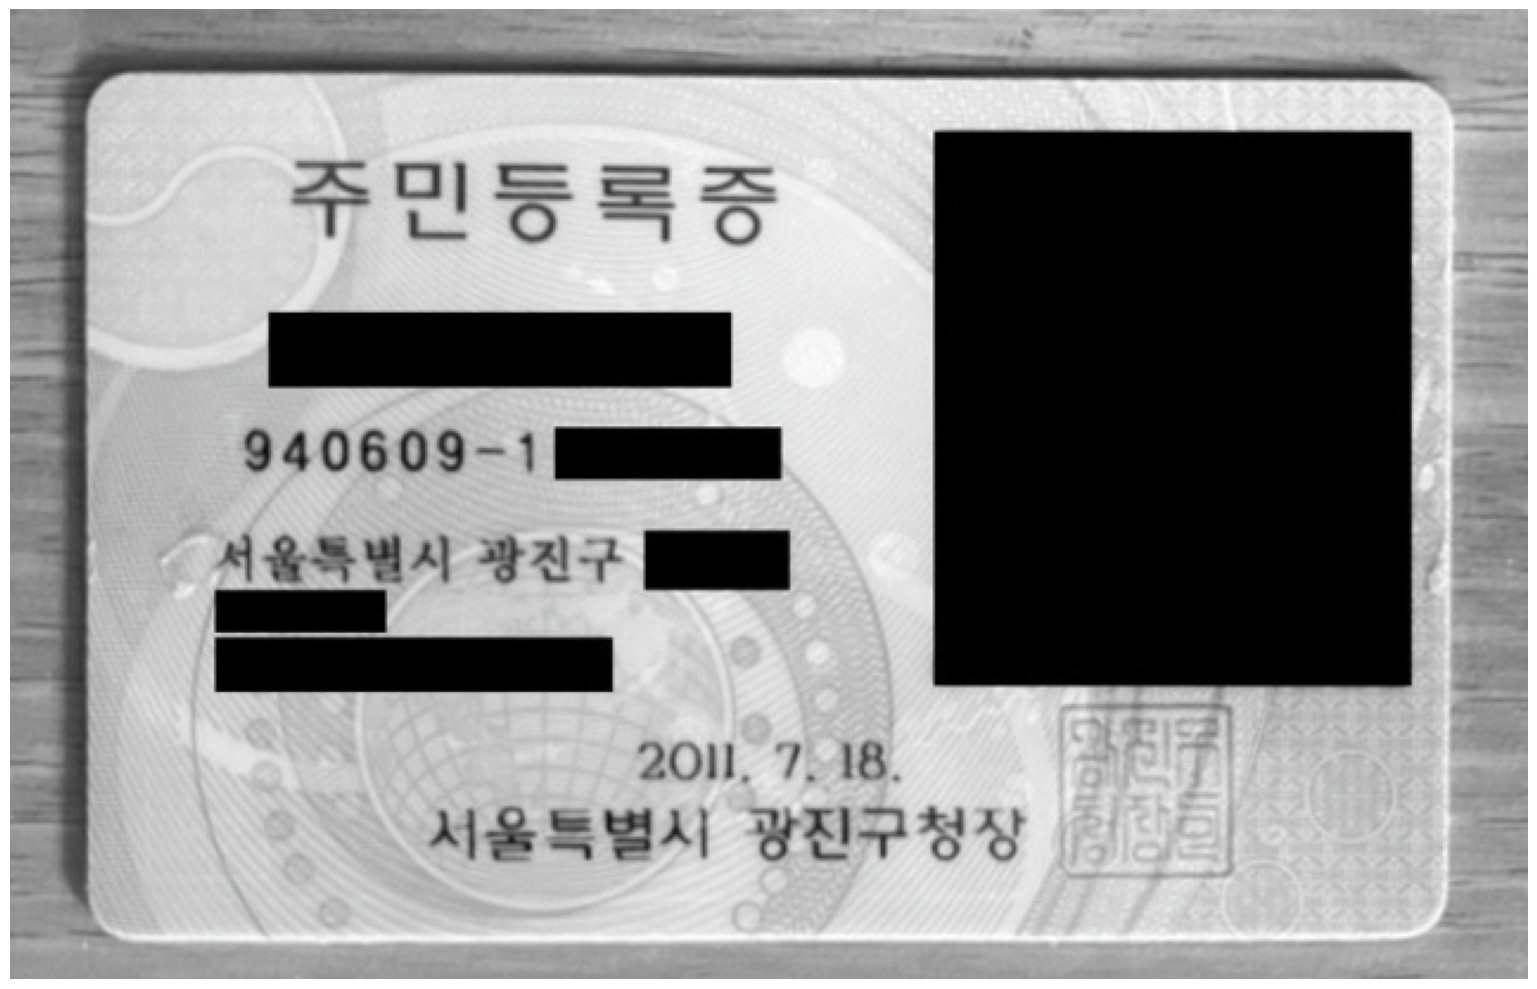

In [3]:
from augraphy import *
import cv2
import matplotlib.pyplot as plt

# 이미지 로드
image = cv2.imread("./f2079413e6c49f35.jpg")
# 팩스 효과로 모노크롬 처리
cp =ColorPaper(
            hue_range=(0, 360),
            saturation_range=(0, 5),  # 매우 낮은 채도
            p=0.7
        )

monochrome_image = cp(image)


plt.figure(figsize=(30, 10))
    
plt.imshow(monochrome_image)
plt.axis('off')
plt.tight_layout()
plt.show()



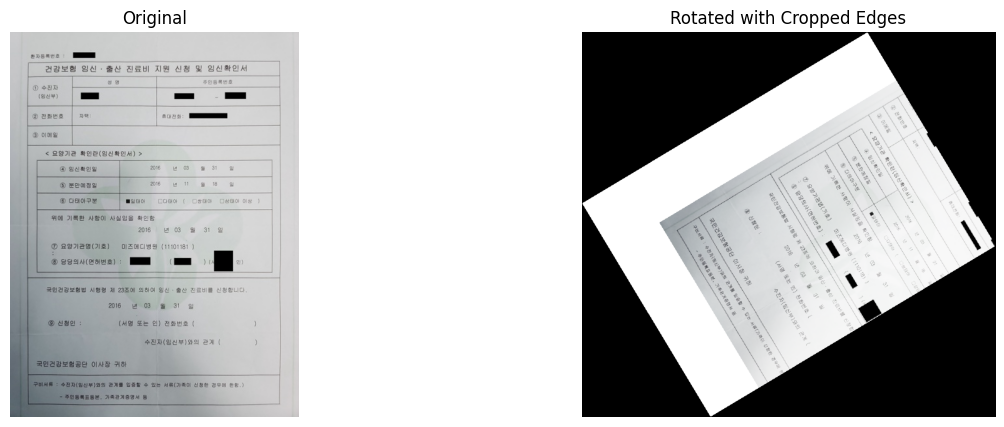

In [4]:
from augraphy import *
import cv2
import matplotlib.pyplot as plt

# 올바른 회전 및 모서리 잘림 효과 파이프라인
pipeline = AugraphyPipeline(
    ink_phase=[
   
    ],
    paper_phase=[

    ],
    post_phase=[
       Geometric(
            rotate_range=(1, 300),
            scale=(1, 1.2),    # 올바른 매개변수명  
            translation=(100, -100),
            fliplr=0.5,
            flipud=0.5,
            #crop=(),
            p=1.0
        ),
        Brightness(brightness_range=(0.95, 1.05), p=0.3)
    ]
)

# 이미지 처리
image = cv2.imread("./0a4adccbb7fe73e0.jpg")
result = pipeline.augment(image)

# 결과 표시
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result["output"], cv2.COLOR_BGR2RGB))
plt.title("Rotated with Cropped Edges")
plt.axis('off')
plt.show()